In [1]:
from dotenv import load_dotenv, find_dotenv
import os
import rich
# 自动向上查找 .env 文件
load_dotenv(find_dotenv())
modelName = os.getenv('OPENAI_MODEL')
print(modelName)

doubao-1-5-pro-32k-250115


# 一、简介

[官方文档](https://docs.langchain.com/oss/python/langgraph/use-time-travel)

"Time Travel" 依赖于 Checkpointer（检查点机制）。

每当 Agent 执行一步操作（比如调用一个工具、生成一段回复），系统都会把当前的“状态（State）”保存下来。

通过这些保存的检查点（Checkpoints），我们可以：

| 能力 | 说明 | 应用场景 |
|------|------|----------|
| **查看（Read）** | 回溯查看 Agent 在过去某一步时的具体状态 | 调试、审计 |
| **重播（Replay）** | 从过去的某一步重新开始执行 | 错误恢复 |
| **分叉（Fork）** | 修改过去某一步的状态，引发新的执行路径 | A/B 测试、修正错误 |

## 1、一个简单案例


我们创建一个简单的笑话生成工作流：
- 节点1：生成笑话主题
- 节点2：以该主题撰写笑话内容

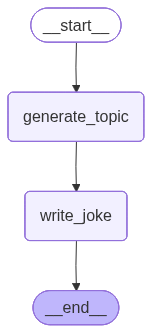

In [49]:
import uuid

from typing_extensions import TypedDict,NotRequired
from langgraph.graph import StateGraph,START,END
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    topic: NotRequired[str]
    joke: NotRequired[str]

model = init_chat_model(model=f"openai:{modelName}")

def generate_topic(state: State):
    """LLM调用生成笑话话题"""
    msg = model.invoke("给我一个有趣的笑话主题，有且只有一个主题")
    return {"topic": msg.content}


def write_joke(state: State):
    """使用LLM基于主题写一个笑话"""
    msg = model.invoke(f"写一个关于 {state['topic']} 的笑话，50字")
    return {"joke": msg.content}


workflow = StateGraph(State)

workflow.add_node("generate_topic", generate_topic)
workflow.add_node("write_joke", write_joke)


workflow.add_edge(START, "generate_topic")
workflow.add_edge("generate_topic", "write_joke")
workflow.add_edge("write_joke", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)
graph

## 2、运行案例

In [58]:
thread_id = str(uuid.uuid4())
config = {
    "configurable": {
        "thread_id": thread_id,
    }
}
state = graph.invoke({}, config)
print(state["topic"])
print(state["joke"])
print(config)

宠物的搞笑行为
我家猫趁我睡觉，叼走我袜子藏沙发后。我找时它在一旁“喵喵”叫，还装作帮忙找，这小戏精太逗啦！ 
{'configurable': {'thread_id': '22a6a61f-7006-4808-b463-642f28d8341e'}}


## 3、查看checkpointer

这里运用 `get_state_history`，获取我们创建的graph图历史运行状态

会返回快照`StateSnapshot` 快照对象

有关这个的分析我在之前的文章已经提及过了

可以点击我的文章跳转过去
[持久化](https://blog.csdn.net/weixin_44238683/article/details/154648157?spm=1001.2014.3001.5501#t5)

下面快照历史共计 4个

In [59]:
states = list(graph.get_state_history(config))

for index,state in enumerate(states):
    print("快照序号：",index)
    print("执行节点名称:",state.next)
    print("当前快照ID：",state.config["configurable"]["checkpoint_id"])
    print("当前状态机值：",state.values)
    print()

快照序号： 0
执行节点名称: ()
当前快照ID： 1f112c3b-26d0-6d08-8002-73fb899ea6f7
当前状态机值： {'topic': '宠物的搞笑行为', 'joke': '我家猫趁我睡觉，叼走我袜子藏沙发后。我找时它在一旁“喵喵”叫，还装作帮忙找，这小戏精太逗啦！ '}

快照序号： 1
执行节点名称: ('write_joke',)
当前快照ID： 1f112c3b-1372-6fa7-8001-be23e661b71e
当前状态机值： {'topic': '宠物的搞笑行为'}

快照序号： 2
执行节点名称: ('generate_topic',)
当前快照ID： 1f112c3b-0578-6506-8000-eadc7c2ef840
当前状态机值： {}

快照序号： 3
执行节点名称: ('__start__',)
当前快照ID： 1f112c3b-0575-600d-bfff-f9239ced4ace
当前状态机值： {}



## 4、更新状态

利用`update_state` 会创建一个新的检查点。新检查点会在同一个`thread_id`关联
但会创建一个新的检查点ID

我们将第一个节点生成的笑话主题更改一下，模拟用户对于用户生成笑话主题不满意

查看序号为2的快照，此时位于，此时准备执行生成笑话topic，即`generate_topic` 节点



In [60]:
selected_state = states[2]
print(selected_state.next )# 输入出下一步要执行的任务
print(selected_state.values) # 当前节点返回的值
print(selected_state.config["configurable"]["checkpoint_id"]) # 当前节点返回的值

('generate_topic',)
{}
1f112c3b-0578-6506-8000-eadc7c2ef840


In [61]:
selected_state.config

{'configurable': {'thread_id': '22a6a61f-7006-4808-b463-642f28d8341e',
  'checkpoint_ns': '',
  'checkpoint_id': '1f112c3b-0578-6506-8000-eadc7c2ef840'}}

In [62]:
new_config = graph.update_state(selected_state.config, values={"topic": "疯狂星期四"})

In [63]:
print(new_config)

{'configurable': {'thread_id': '22a6a61f-7006-4808-b463-642f28d8341e', 'checkpoint_ns': '', 'checkpoint_id': '1f112c43-70b3-6131-8001-73dd38b08181'}}


In [65]:
states = list(graph.get_state_history(config))

for index,state in enumerate(states):
    print("快照序号：",index)
    print("执行节点名称:",state.next)
    print("当前快照ID：",state.config["configurable"]["checkpoint_id"])
    print("当前状态机值：",state.values)
    print()

快照序号： 0
执行节点名称: ('write_joke',)
当前快照ID： 1f112c43-70b3-6131-8001-73dd38b08181
当前状态机值： {'topic': '疯狂星期四'}

快照序号： 1
执行节点名称: ()
当前快照ID： 1f112c3b-26d0-6d08-8002-73fb899ea6f7
当前状态机值： {'topic': '宠物的搞笑行为', 'joke': '我家猫趁我睡觉，叼走我袜子藏沙发后。我找时它在一旁“喵喵”叫，还装作帮忙找，这小戏精太逗啦！ '}

快照序号： 2
执行节点名称: ('write_joke',)
当前快照ID： 1f112c3b-1372-6fa7-8001-be23e661b71e
当前状态机值： {'topic': '宠物的搞笑行为'}

快照序号： 3
执行节点名称: ('generate_topic',)
当前快照ID： 1f112c3b-0578-6506-8000-eadc7c2ef840
当前状态机值： {}

快照序号： 4
执行节点名称: ('__start__',)
当前快照ID： 1f112c3b-0575-600d-bfff-f9239ced4ace
当前状态机值： {}



用户修改完成后，我们继续执行，因为我们是沿用`thread_id` 创建了一个新的分支路径
所以要使用`new_config`这个参数运行

上面面快照历史共计 5个，比之前多了一个，我们可以看到

历史快照保留了，但是新创建了一个检查节点，查看堆栈
`1f112c43-70b3-6131-8001-73dd38b08181`



说明update_state方法，是基于当前要更新的节点，创建一个继承分支，保留历史

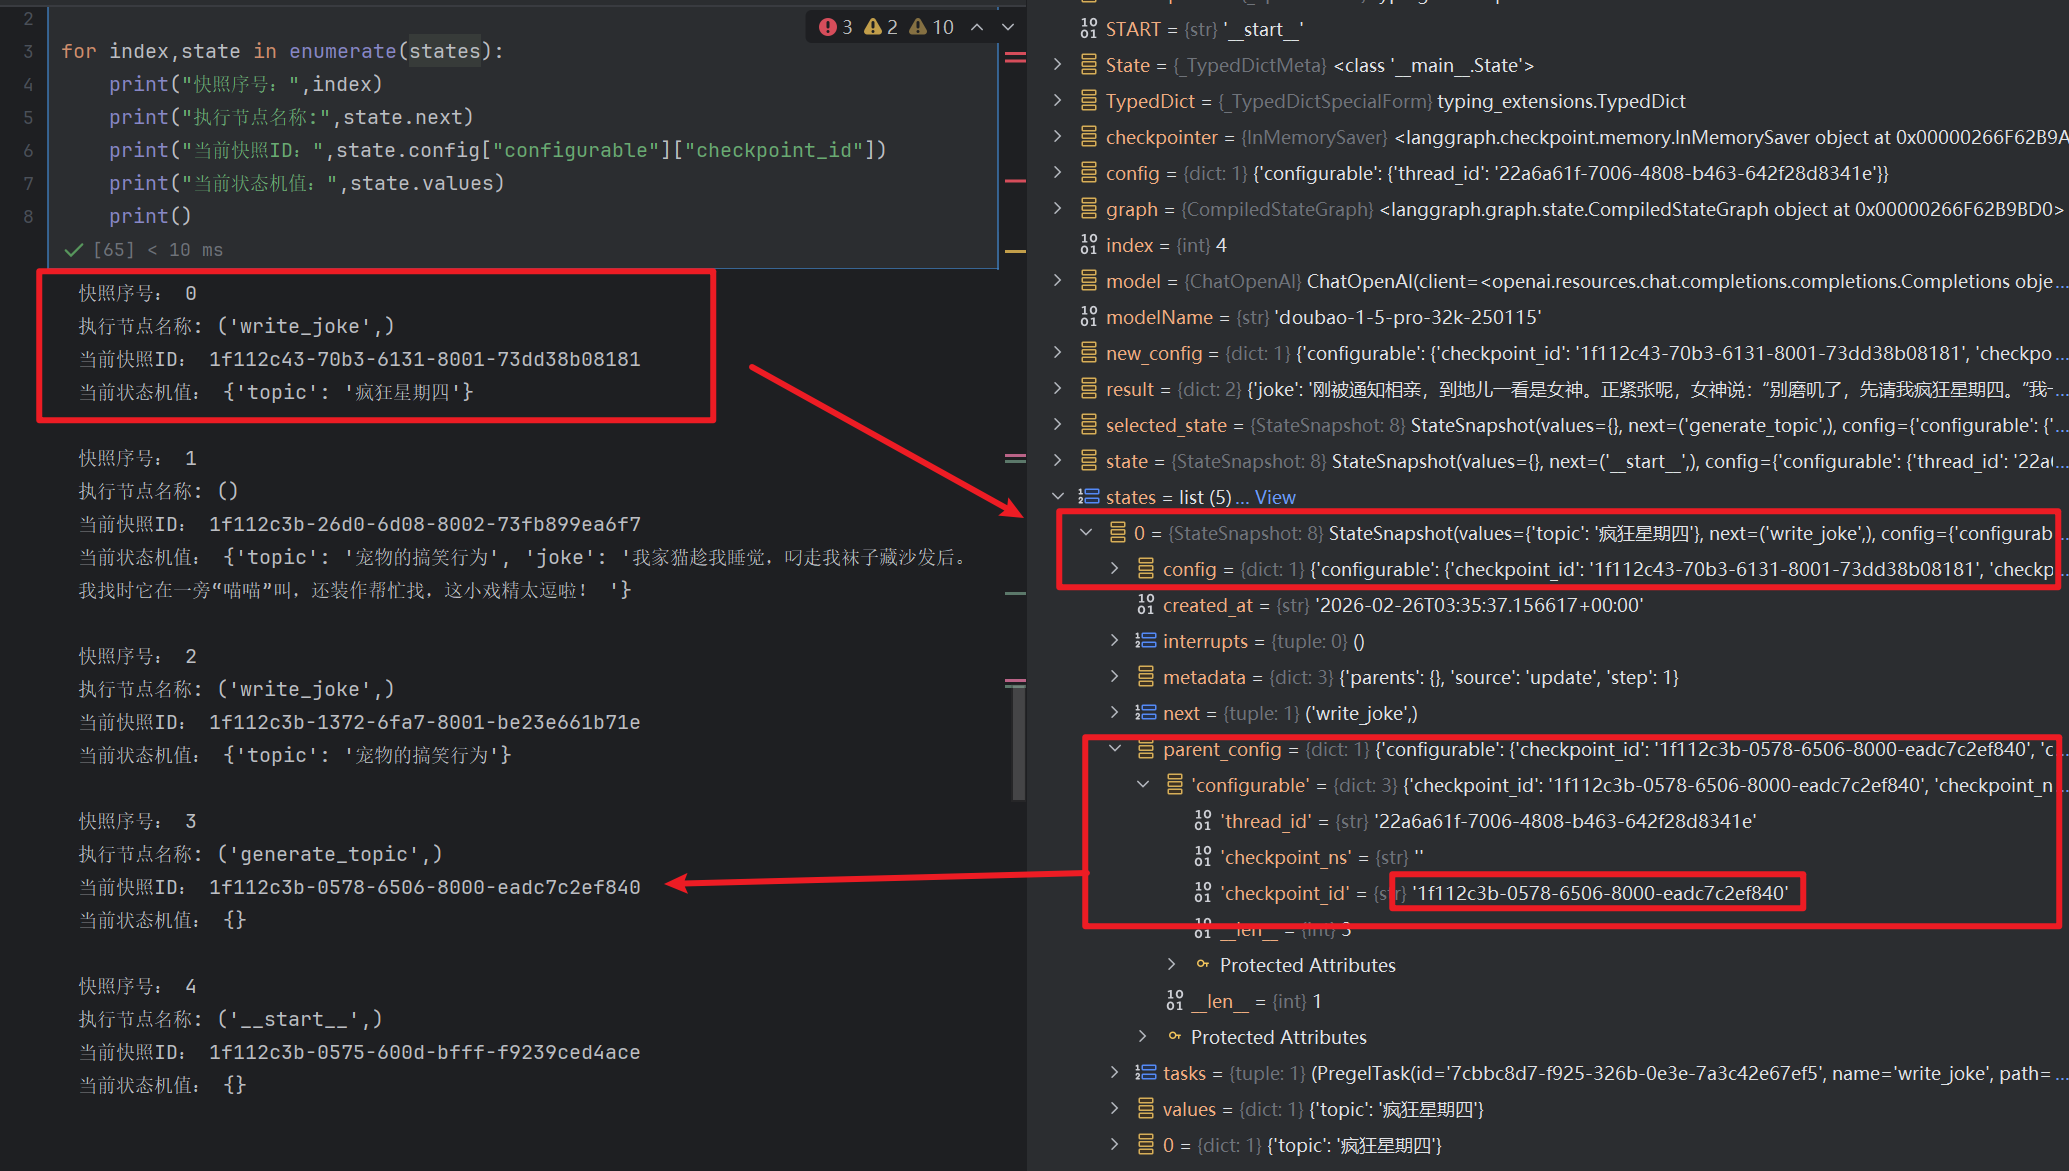

In [66]:
# 选项1：从创建的新checkpoint分支继续执行
result = graph.invoke(None, new_config)
print(result)  # 输出使用"疯狂星期四"作为topic生成的笑话

{'topic': '疯狂星期四', 'joke': '刚被通知相亲，到地儿一看是女神。正紧张呢，女神说：“别磨叽了，先请我疯狂星期四。”我一咬牙：“V我50！” '}


In [68]:
def visualize_state_tree(graph, config):
    """可视化状态树结构"""

    states = list(graph.get_state_history(config))

    # 构建父子关系映射
    checkpoint_map = {}
    for state in states:
        checkpoint_id = state.config["configurable"]["checkpoint_id"]
        parent_id = None
        if state.parent_config:
            parent_id = state.parent_config["configurable"]["checkpoint_id"]

        checkpoint_map[checkpoint_id] = {
            "state": state,
            "parent": parent_id,
            "children": []
        }

    # 建立子节点关系
    for cid, data in checkpoint_map.items():
        if data["parent"] and data["parent"] in checkpoint_map:
            checkpoint_map[data["parent"]]["children"].append(cid)

    # 找到根节点
    root = None
    for cid, data in checkpoint_map.items():
        if data["parent"] is None:
            root = cid
            break

    # 递归打印树
    def print_tree(checkpoint_id, prefix="", is_last=True):
        data = checkpoint_map[checkpoint_id]
        state = data["state"]

        # 树形符号
        connector = "└── " if is_last else "├── "

        # 状态信息
        step = state.metadata.get("step", "?")
        topic = state.values.get("topic", "无主题")
        is_current = state == states[0]

        # 打印节点
        status = "🟢 当前" if is_current else "🔴 历史"
        print(f"{prefix}{connector}{status} Step {step}: {topic[:25]}")

        # 递归打印子节点
        children = data["children"]
        for i, child_id in enumerate(children):
            is_last_child = (i == len(children) - 1)
            extension = "    " if is_last else "│   "
            print_tree(child_id, prefix + extension, is_last_child)

    print("\n" + "=" * 60)
    print("🌳 状态树结构")
    print("=" * 60)
    if root:
        print_tree(root)
    print()

# 使用示例
visualize_state_tree(graph, config)


🌳 状态树结构
└── 🔴 历史 Step -1: 无主题
    └── 🔴 历史 Step 0: 无主题
        ├── 🔴 历史 Step 1: 疯狂星期四
        │   └── 🟢 当前 Step 2: 疯狂星期四
        └── 🔴 历史 Step 1: 宠物的搞笑行为
            └── 🔴 历史 Step 2: 宠物的搞笑行为



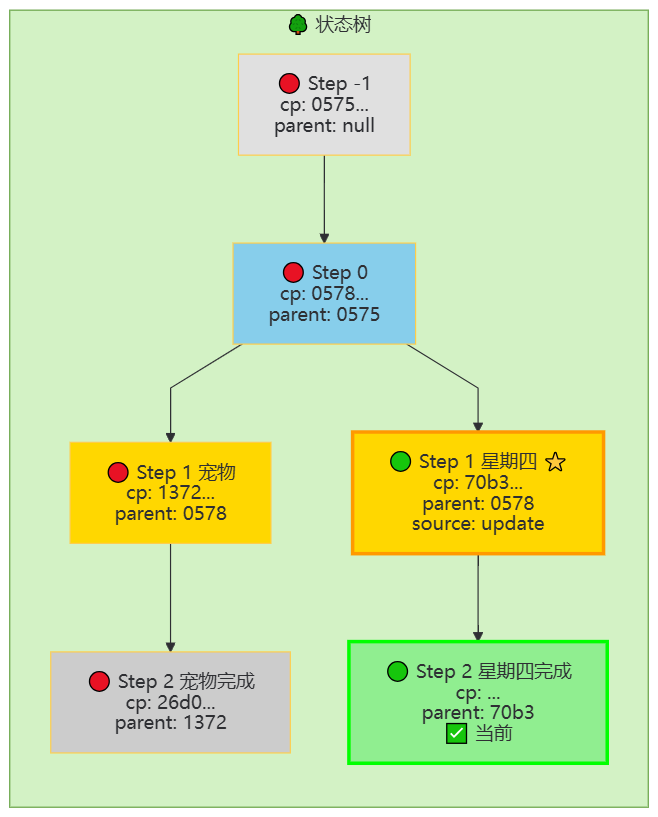